# SIFT - Harris
### SIFT - Harris


maximum_filter:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.maximum_filter.html
gaussian_filter:https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.filters.gaussian_filter.html
sobel:https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.sobel.html

matplotlib.patches: https://matplotlib.org/api/patches_api.html

np.where: https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.where.html
np.argwhere: https://docs.scipy.org/doc/numpy-1.15.1/reference/generated/numpy.argwhere.html

In [ ]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


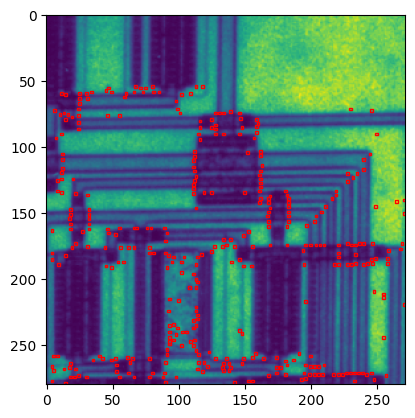

In [7]:
from skimage.filters import gaussian
from scipy.ndimage import maximum_filter,gaussian_filter,sobel
import matplotlib.patches as patches

eps=1e-6
img = io.imread('circuit.tif').astype(float);

# TODO perform gaussian_filter, this will make the image less noisy not a step in the Harris algorithm
img_blur = gaussian_filter(img, sigma=1)

# TODO perform sobel to get x-change and y-change
Ix = sobel(img_blur, axis=1)
Iy = sobel(img_blur, axis=0)


# In the following 3 TODOs, we are using a guassian as our window function. 
# We could have just used an averaging filter.
# TODO perform gaussian_filter on x-change * x-change to get sum of Ixx (i.e Sx2)
Sx2 = gaussian_filter(Ix * Ix, sigma=1)
# TODO perform gaussian_filter on x-change * y-change to get sum of Ixy (i.e Sxy)
Sxy = gaussian_filter(Ix * Iy, sigma=1)
# TODO perform gaussian_filter on y-change * y-change to get sum of Iyy (i.e Sy2)
Sy2 = gaussian_filter(Iy * Iy, sigma=1)

# TODO Get R value using the supplied equations (use **2 for power 2)
k = 0.04
R = (Sx2 * Sy2 - Sxy ** 2) - k * (Sx2 + Sy2) ** 2

# TODO Get the R values which are local maximum and above a given threshold. 
# The maximum_filter will help you get the max value in a neighborhood.
R_max = maximum_filter(R, size=3)
threshold = 0.01 * R.max()
z = (R == R_max) & (R > threshold)


# From here we will assume that z is a binary mask where 1 means there is a corner
# This part will get the indices of z where z = true, then we will draw a small rectangle around those indices
indx = np.argwhere(z==True)

fig,ax = plt.subplots(1)
ax.imshow(img)

for ind in indx:
    rect = patches.Rectangle((ind[1],ind[0]),2,2,linewidth=1,edgecolor='r',facecolor='none')
    ax.add_patch(rect)
plt.show()

In [8]:
import numpy as np
import cv2
from matplotlib import pyplot as plt


sift = cv2.SIFT_create()

## TODO: read image box.png and box_in_scene
img1 = cv2.imread('box.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('box_in_scene.png', cv2.IMREAD_GRAYSCALE)


## TODO: find the keypoints and descriptors with SIFT
# Use sift.detectAndCompute
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)


#Draw keypoints of img1 using cv2.drawKeypoints
img1_kp = cv2.drawKeypoints(img1, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize=(8, 8))
plt.title('SIFT Keypoints - box.png')
plt.imshow(img1_kp, cmap='gray')
plt.axis('off')
plt.show()


## TODO: Construct BFMatcher, Hint use cv2.BFMatcher
## Use knnMatch with k = 2 to get the matches between the descriptors 
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)


## TODO: Apply ratio test to remove ambigiuous matched (points that has multiple matches)
## Hint: use the distance in match 
## For k=2 knnMatch return the 2 closest matches anyways.
## if the distance between the keypoints and its 2 neighbours is close, then the keypoint is ambigious and 
## you should neglect it
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append([m])



## TODO: Draw the matches features use cv2.drawMatchesKnn with flags =4 
img3 = cv2.drawMatchesKnn(img1, kp1, img2, kp2, good_matches, None, flags=4)
plt.figure(figsize=(16, 8))
plt.title('Good Matches')
plt.imshow(img3)
plt.axis('off')
plt.show()



# plt.imshow(img3),plt.show()

ModuleNotFoundError: No module named 'cv2'